---
## 9. Dataset 3 - Percepcion de reemplazo por IA y nivel de agotamiento

Los siguientes 4 graficos de dispersion analizan la relacion entre la percepcion de reemplazo por IA y el nivel de agotamiento, uno por celda.
Se utiliza el dataset original Data_set_03.csv, con las variables ai_replaces_my_tasks_pct y burnout_score (presentada como nivel de agotamiento).

Cada grafico incluye media, mediana, desviacion estandar y correlacion para facilitar la interpretacion estadistica.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset usado
df_ds3 = pd.read_csv('./Dataset/Data_set_03.csv')

# Se usan las 4 profesiones mas repetidas del dataset
profesiones = df_ds3['job_role'].value_counts().head(4).index.tolist()

def graficar_profesion(df, profesion):
    df_prof = df[df['job_role'] == profesion]

    x = df_prof['ai_replaces_my_tasks_pct']
    y = df_prof['burnout_score']

    y_mean = y.mean()
    y_std = y.std(ddof=1)
    y_median = y.median()
    corr = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=34, color='#2f5597', alpha=0.35, edgecolors='none', label='Observaciones')
    plt.plot(x_line, y_line, color='#c23b22', linewidth=2.2, label='Tendencia lineal')

    plt.axhline(y_mean, color='#a61c00', linewidth=2.2, label=f'Media = {y_mean:.2f}')
    plt.axhline(y_median, color='#38761d', linestyle='--', linewidth=2.2, label=f'Mediana = {y_median:.2f}')
    plt.axhline(y_mean - y_std, color='#ed7d31', linestyle=':', linewidth=2)
    plt.axhline(y_mean + y_std, color='#ed7d31', linestyle=':', linewidth=2, label=f'Desv. est. = {y_std:.2f}')

    plt.text(
        0.02, 0.98,
        f'n = {len(df_prof)}\nMedia = {y_mean:.2f}\nMediana = {y_median:.2f}\nDesv. est. = {y_std:.2f}\nCorrelacion r = {corr:.3f}',
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#b7b7b7')
    )

    plt.title(f'Percepcion de reemplazo por IA vs nivel de agotamiento\n{profesion}')
    plt.xlabel('Percepcion de reemplazo por IA (%)')
    plt.ylabel('Nivel de agotamiento')
    plt.grid(True, alpha=0.25)
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

print('Profesiones seleccionadas:')
for i, profesion in enumerate(profesiones, start=1):
    print(f'{i}. {profesion}')

Profesiones seleccionadas:
1. Software Engineer
2. AI Researcher
3. Data Scientist
4. AI Ethics Officer


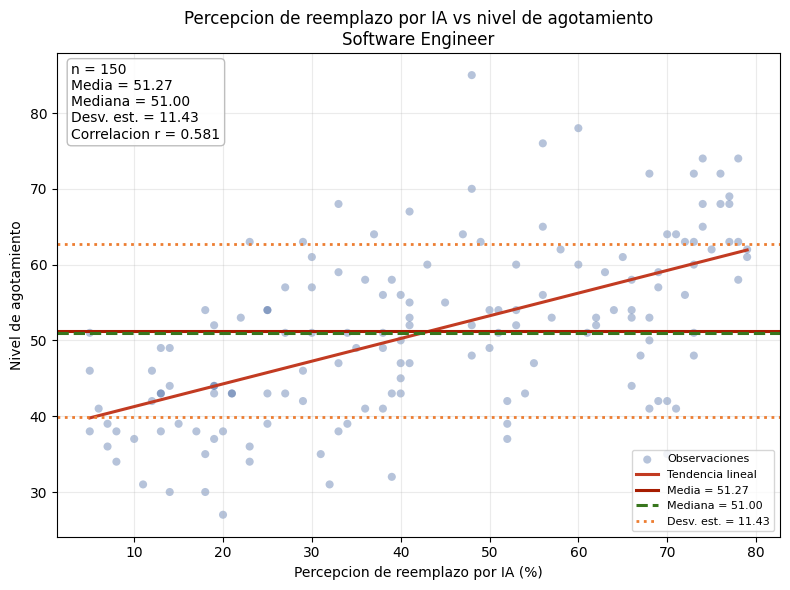

In [ ]:
# Grafico 1
graficar_profesion(df_ds3, profesiones[0])

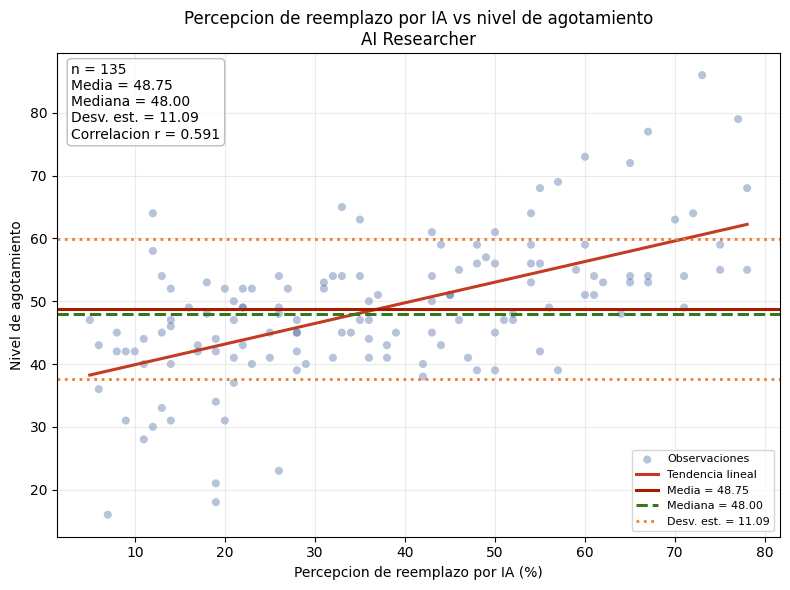

In [ ]:
# Grafico 2
graficar_profesion(df_ds3, profesiones[1])

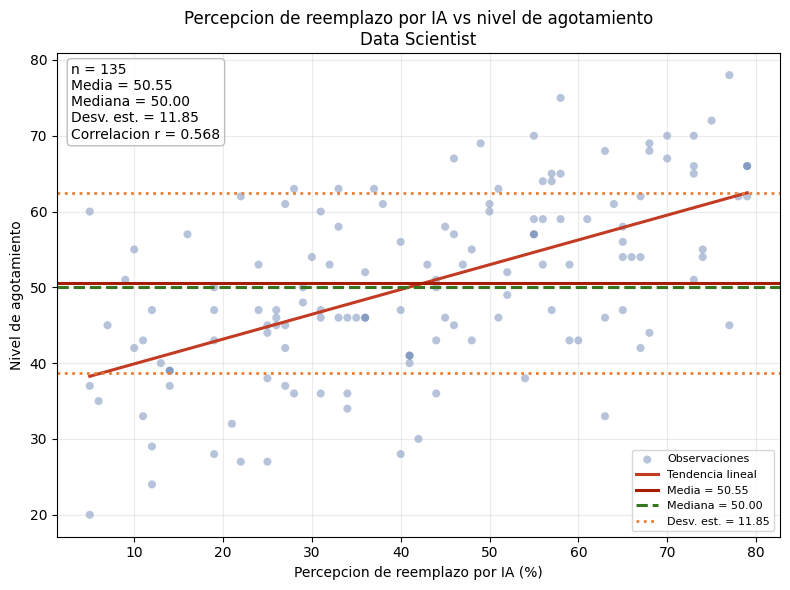

In [ ]:
# Grafico 3
graficar_profesion(df_ds3, profesiones[2])

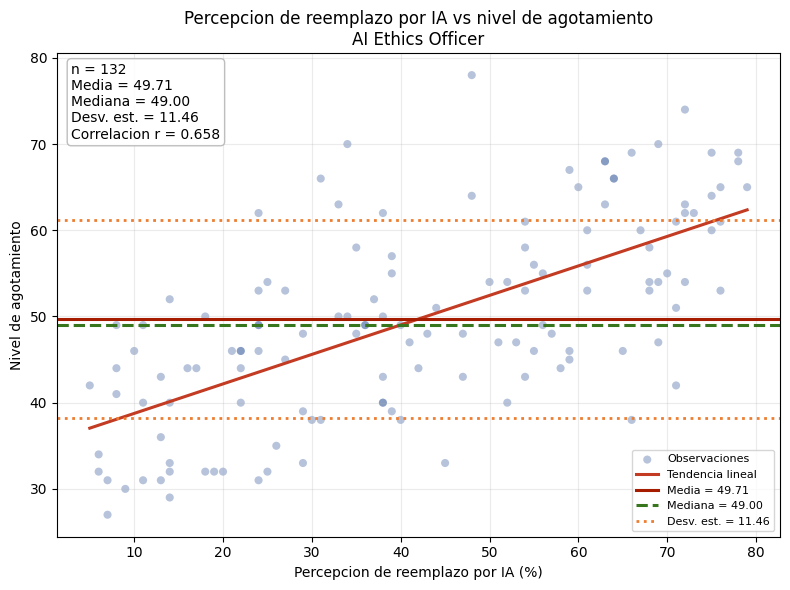

In [ ]:
# Grafico 4
graficar_profesion(df_ds3, profesiones[3])

### Casilla de interpretacion simple

En los 4 graficos se observa una tendencia positiva: cuando sube la percepcion de reemplazo por IA, tambien sube el nivel de agotamiento.

Interpretacion rapida por profesion:
- Software Engineer: es el grupo con mayor agotamiento promedio (media = 51.27).
- AI Researcher: muestra el menor agotamiento promedio (media = 48.75).
- Data Scientist: tiene un nivel intermedio de agotamiento (media = 50.55) y la correlacion mas baja (r = 0.568).
- AI Ethics Officer: es donde mas fuerte se relaciona el miedo al reemplazo con el agotamiento (correlacion r = 0.658).


- Si miramos quien se siente peor en promedio, es Software Engineer.
- Si miramos quien se siente menos afectado en promedio, es AI Researcher.
- Si miramos a quien le afecta mas la idea de reemplazo de IA, es AI Ethics Officer.
